In [6]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

In [7]:
data = pd.read_csv('netflix.csv',index_col='Rank')

In [8]:
data


,Movie Title,Year,Score,Director,Cast,Critics Consensus
Rank,,,,,,
1,His House,2020,100,Remi Weekes,"Wunmi Mosaku, Sope Dirisu, Matt Smith, Cornell...",Featuring genuine scares through every corrido...
2,How to Train Your Dragon,2010,99,Christopher Sanders,"Jay Baruchel, Gerard Butler, America Ferrera, ...","Boasting dazzling animation, a script with sur..."
3,The Forty-Year-Old Version,2020,99,Radha Blank,"Welker White, Reed Birney, Radha Blank, Peter Kim",The Forty-Year-Old Version opens a compelling ...
4,Under the Shadow,2016,99,Babak Anvari,"Narges Rashidi, Avin Manshadi, Bobby Naderi, R...",Under the Shadow deftly blends seemingly dispa...
5,Monty Python and the Holy Grail,1975,98,Terry Gilliam,"Graham Chapman, John Cleese, Terry Gilliam, Er...",A cult classic as gut-bustingly hilarious as i...
...,...,...,...,...,...,...
96,Fear Street Part Three: 1666,2021,88,Leigh Janiak,"Kiana Madeira, Ashley Zukerman, Gillian Jacobs...",Fear Street Part Three: 1666 sends the slasher...
97,Donnie Brasco,1997,88,Mike Newell,"Al Pacino, Johnny Depp, Michael Madsen, Bruno ...","A stark, nuanced portrait of life in organized..."
98,Inception,2010,87,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ellio...","Smart, innovative, and thrilling, Inception is..."


What is the distribution of movie scores in the dataset? Are there any notable trends or patterns?

In [9]:
data['Score'].mean()

92.52

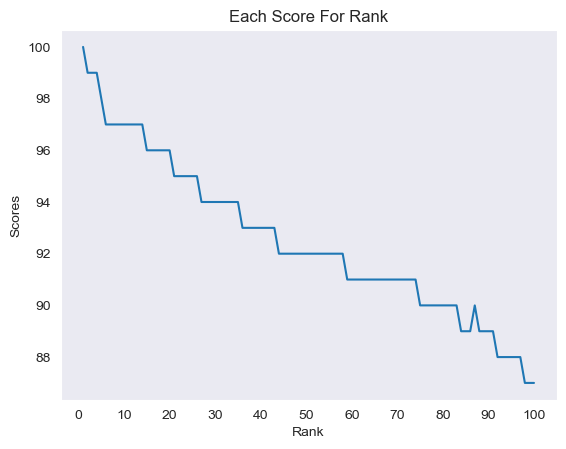

In [10]:
plt.plot(data.index,data['Score'])
plt.ylabel('Scores')
plt.xlabel('Rank')
plt.title('Each Score For Rank')
plt.grid()
plt.xticks(np.array(range(0,110,10)))
plt.show()

Which movie(s) received the highest score? Who was the director and what year was it released?

In [11]:
maxscore = max(data['Score'])
filt = data['Score'] == maxscore

data[filt][['Movie Title','Director','Year']]

,Movie Title,Director,Year
Rank,,,
1,His House,Remi Weekes,2020


Who are the top 5 directors with the most movies in the dataset? How many movies did each of them direct?

In [12]:
data.groupby('Director').count()['Movie Title'].sort_values(ascending=False)[0:5]

Director
Peter Jackson     3
Noah Baumbach     2
Sam Mendes        2
Sam Raimi         2
Jeremiah Zagar    2
Name: Movie Title, dtype: int64

What is the average score of movies released each year? Is there any noticeable trend in movie scores over time?

In [13]:
yearscore = data.groupby('Year').mean()['Score']
yearscore

Year
1960    96.000000
1963    94.000000
1975    98.000000
1976    92.000000
1978    91.000000
1979    96.000000
1987    91.000000
1989    91.500000
1992    90.000000
1995    90.000000
1997    88.000000
1998    95.000000
1999    87.000000
2001    91.000000
2002    91.666667
2003    93.000000
2004    93.000000
2007    92.000000
2008    92.000000
2009    89.500000
2010    93.000000
2011    91.000000
2012    91.500000
2013    92.000000
2014    92.500000
2015    91.250000
2016    94.125000
2017    92.555556
2018    93.000000
2019    93.230769
2020    94.285714
2021    91.000000
2022    91.750000
Name: Score, dtype: float64

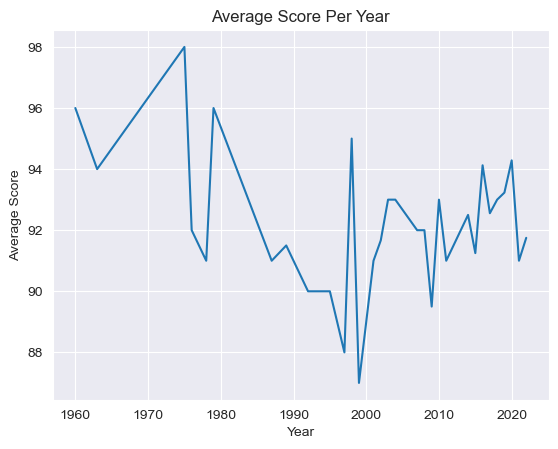

In [14]:
plt.plot(yearscore.index,yearscore.values)
plt.title('Average Score Per Year')
plt.xlabel('Year')
plt.ylabel('Average Score')
plt.show()

How many movies in the dataset have a critics consensus? What percentage of movies have a consensus?

In [15]:
data['Critics Consensus'].isna().sum()

0

- No empty Critics. Every movie has a critics consensus.

Is there any correlation between the movie score and the number of cast members in the movie?

In [30]:
number_of_cast_members = list(map(len,list(x.split(sep=',') for x in data['Cast'])))

In [33]:
np.corrcoef(data['Score'],number_of_cast_members)

array([[1.        , 0.01714696],
       [0.01714696, 1.        ]])